In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# some initial tests

## model

In [2]:
from b_models.hsami.recnet_conv import RecNetConv
from b_models.hsami.denoiser_conv import DenoiserConv
from b_models.hsami.denoiser import Denoiser
from b_models.hsami.hsami_conv import HSAMI
from b_models.configs.hsami_config import HSAMI_Image_Training_Config

config = HSAMI_Image_Training_Config()

recnet = RecNetConv(config).to(device)

denoiser_x = DenoiserConv(args=config).to(device)
denoiser_y = Denoiser(
    input_dim=config.latent_dim_y, 
    hidden_dim=config.hidden_dim_den_y, 
    num_blocks=config.num_blocks_den_y, 
    time_dim=config.time_dim_den_y, 
    activation=config.activation_den_y,    
).to(device)

hsami = HSAMI(
    recnet=recnet,
    denoiser_x=denoiser_x,
    denoiser_y=denoiser_y,
    args=config
).to(device)

In [3]:
test_image = torch.randn(1, 1, config.input_dim, config.input_dim).to(device)

target_x, prediction_x, target_y, prediction_y, weight, rate_y, rate_z, debug_norms = hsami(test_image)

print(target_x.shape)
print(prediction_x.shape)
print(target_y.shape)
print(prediction_y.shape)
print(weight.shape)
print(rate_y.shape)
print(rate_z.shape)

torch.Size([1, 1, 32, 32])
torch.Size([1, 1, 32, 32])
torch.Size([1, 2])
torch.Size([1, 2])
torch.Size([1, 1, 1, 1])
torch.Size([1])
torch.Size([1, 32, 32])


# hierarchical disks

In [2]:
from a_datasets.hierarchical_disks.data import load_hierarchical_disk_dataset

cpu_tensor, (z, x, y) = load_hierarchical_disk_dataset()

In [3]:
img = cpu_tensor
print(img.shape)

torch.Size([2000, 1, 28, 28])


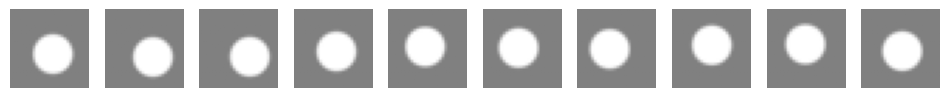

In [4]:
fig, ax = plt.subplots(1, 10, figsize=(12, 4))
for idx, img in enumerate(cpu_tensor[0][0][:10]):
    ax[idx].imshow(cpu_tensor[idx][0], cmap='gray', vmin=-1, vmax=1)
    ax[idx].axis('off')

## two disk hierarchical dataset

In [8]:
from a_datasets.hierarchical_two_disks.data import HierarchicalTwoDiskIntensityDataset, load_hierarchical_two_disk_intensity_dataset
from a_datasets.h2disks.data import load_dataset, normalize_to_pm1

# cpu_tensor, latents, info = load_hierarchical_two_disk_intensity_dataset(grid_size=28, outer_radius=5)
cpu_tensor, latents, info = load_dataset(transform=normalize_to_pm1)

In [9]:
cpu_tensor.min()

tensor(-1.)

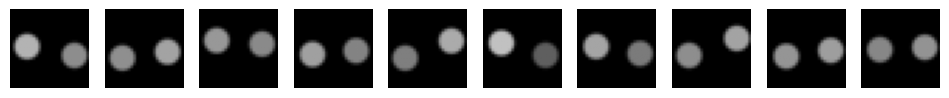

In [12]:
fig, ax = plt.subplots(1, 10, figsize=(12, 4))
for idx, img in enumerate(cpu_tensor[0][0][:10]):
    ax[idx].imshow(cpu_tensor[idx][0], cmap='gray', vmin=-1, vmax=1)
    ax[idx].axis('off')

# train - start here for training

In [2]:
from b_models.hsami.recnet_conv import RecNetConv
from b_models.hsami.denoiser_conv import DenoiserConv
from b_models.hsami.denoiser import Denoiser
from b_models.hsami.hsami_conv import HSAMI
from b_models.configs.hsami_config import HSAMI_Image_Training_Config

config = HSAMI_Image_Training_Config()

recnet = RecNetConv(config).to(device)

denoiser_x = DenoiserConv(args=config).to(device)
denoiser_y = Denoiser(
    input_dim=config.latent_dim_y, 
    hidden_dim=config.hidden_dim_den_y, 
    num_blocks=config.num_blocks_den_y, 
    time_dim=config.time_dim_den_y, 
    activation=config.activation_den_y,    
).to(device)

hsami = HSAMI(
    recnet=recnet,
    denoiser_x=denoiser_x,
    denoiser_y=denoiser_y,
    args=config
).to(device)

In [ ]:
# now train the dataset
from b_models.hsami.sequential_training_image import train
train()

device: cuda
parameters: 1,173,551
run dir: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_h2disks/sequential_20260704_205813
loaded checkpoint: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_h2disks/sequential_20260703_162708/stage1_epoch_003000.pt
  restored 36 tensors (prefixes: denoiser_x.)
t_y curriculum: hard_max=92 (sqrt_ab=0.1), full range in 40000 steps
=== Stage 4: full training (10000 epochs) ===
[stage4] epoch     0 | step       0 | loss 1.1345 | mse_x 0.0063 | mse_y 1.1282 | rate_y 10873.3066 | rate_z 94.6531 | beta_y 1.00e-08 | t_y_max 92/99
  norms: raw_mse_x 6.126e-03 | raw_mse_y 1.078e+00 | pred_noise_y 2.484e-01 | score_x|ye 3.231e+00 | score_xz|ye 3.255e+00 | score_z|ye 2.048e-01 | score_y|xg 1.180e-02 | pred_y_unguided 1.613e+00 | pred_y_guided_by_xz 1.266e+01
  probe R^2: z->d 0.244 | yz->d 0.734 | y->I 0.615 | y->cy 0.810 | std_y 0.239 | std_z 1.129 | I(z;x)nats 1.265
[stage4] epoch    20 | step     380 | loss 0.2462 | mse_x 0

# let's test the full model

## get test input

In [6]:
# from a_datasets.hierarchical_two_disks.data import load_hierarchical_two_disk_intensity_dataset
from a_datasets.h2disks.data import load_dataset, normalize_to_pm1

cpu_tensor, _, _ = load_dataset(transform=normalize_to_pm1)

torch.Size([1, 1, 28, 28])


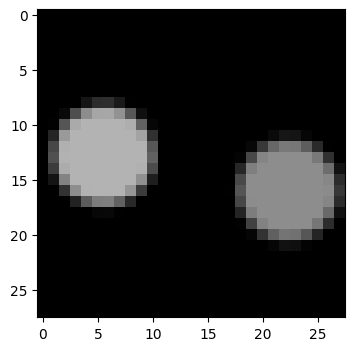

In [7]:
test_input = cpu_tensor[0].unsqueeze(dim=0)
print(test_input.shape)

test_input_gpu = test_input.to(device)

# plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(test_input.squeeze(), cmap='gray', vmin=-1, vmax=1)

## conditional generation (full model)

In [8]:
# load weights
from b_models.configs.hsami_config import HSAMI_Image_Training_Config

checkpoint_base = "/mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_h2disks"
run_name = "sequential_20260703_204037"

config_path = os.path.join(checkpoint_base, run_name, "config.json")
config = HSAMI_Image_Training_Config()
config.load_from_json(config_path)

In [9]:
from b_models.hsami.recnet_conv import RecNetConv
from b_models.hsami.denoiser_conv import DenoiserConv
from b_models.hsami.denoiser import Denoiser
from b_models.hsami.hsami_conv import HSAMI
from b_models.hsami.sequential_training_ring import load_stage_checkpoint

recnet = RecNetConv(config).to(device)

denoiser_x = DenoiserConv(args=config).to(device)
denoiser_y = Denoiser(
    input_dim=config.latent_dim_y, 
    hidden_dim=config.hidden_dim_den_y, 
    num_blocks=config.num_blocks_den_y, 
    time_dim=config.time_dim_den_y, 
    activation=config.activation_den_y,    
).to(device)

hsami = HSAMI(
    recnet=recnet,
    denoiser_x=denoiser_x,
    denoiser_y=denoiser_y,
    args=config
).to(device)

stage = 4
load_stage_checkpoint(hsami, checkpoint_base, run_name, stage, device)

loaded checkpoint: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_h2disks/sequential_20260703_204037/stage4_epoch_010000.pt
  restored 92 tensors (prefixes: denoiser_x., recnet.layers_x_to_y., recnet.head_y., denoiser_y., recnet.input_head_y., recnet.layers_y_to_z., recnet.head_z.)


In [10]:
N = 10

stage4_samples = hsami.conditional_generation(N, target_x=test_input_gpu)
stage4_samples.shape

/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


torch.Size([10, 1, 28, 28])

In [11]:
print('min:', stage4_samples.min())
print('max:', stage4_samples.max())

min: tensor(-1.4798, device='cuda:0')
max: tensor(0.8543, device='cuda:0')


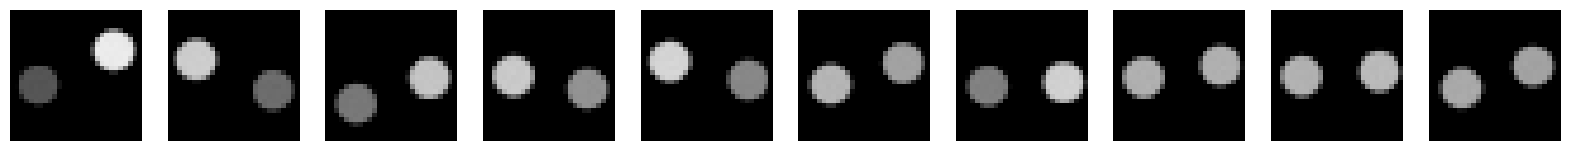

In [12]:
fig, ax = plt.subplots(1, N, figsize=(20, 4))
for idx in range(N):
    ax[idx].imshow(stage4_samples[idx][0].cpu().detach().numpy(), cmap='gray', vmin=-1, vmax=1)
    # ax[idx].imshow(stage4_samples[idx][0].cpu().detach().numpy(), cmap='gray')
    ax[idx].axis('off')

## conditional generation (2 stages -- i.e. single stage model)

In [10]:
# load weights
from b_models.configs.hsami_config import HSAMI_Image_Training_Config

checkpoint_base = "/mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_h2disks"
run_name = "sequential_20260702_233406"

config_path = os.path.join(checkpoint_base, run_name, "config.json")
config = HSAMI_Image_Training_Config()
config.load_from_json(config_path)

In [8]:
from b_models.hsami.recnet_conv import RecNetConv
from b_models.hsami.denoiser_conv import DenoiserConv
from b_models.hsami.denoiser import Denoiser
from b_models.hsami.hsami_conv import HSAMI
from b_models.hsami.sequential_training_ring import load_stage_checkpoint

recnet = RecNetConv(config).to(device)

denoiser_x = DenoiserConv(args=config).to(device)
denoiser_y = Denoiser(
    input_dim=config.latent_dim_y, 
    hidden_dim=config.hidden_dim_den_y, 
    num_blocks=config.num_blocks_den_y, 
    time_dim=config.time_dim_den_y, 
    activation=config.activation_den_y,    
).to(device)

hsami = HSAMI(
    recnet=recnet,
    denoiser_x=denoiser_x,
    denoiser_y=denoiser_y,
    args=config
).to(device)

stage = 2
load_stage_checkpoint(hsami, checkpoint_base, run_name, stage, device)

loaded checkpoint: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_hdisks/sequential_20260702_030225/stage2_epoch_004000.pt
  restored 42 tensors (prefixes: denoiser_x., recnet.layers_x_to_y., recnet.head_y.)


In [9]:
N = 10
stage2_samples = hsami.stage2_generation(N, target_input=test_input_gpu)
stage2_samples.shape

torch.Size([10, 1, 28, 28])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

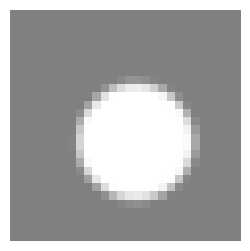

In [10]:
test_input = cpu_tensor[0].unsqueeze(dim=0)
# plot
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(test_input.squeeze(), cmap='gray', vmin=-1, vmax=1)
ax.axis('off')

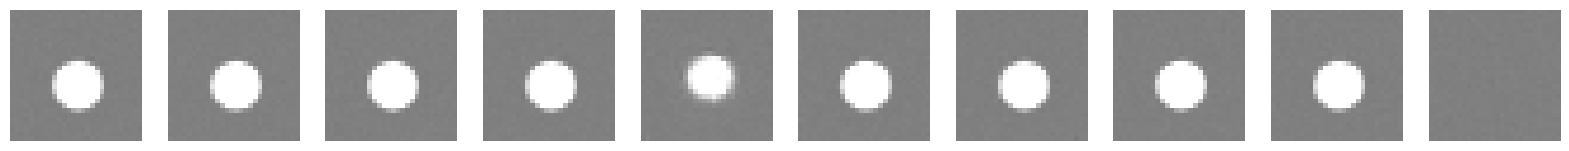

In [11]:
fig, ax = plt.subplots(1, N, figsize=(20, 4))
for idx in range(N):
    ax[idx].imshow(stage2_samples[idx][0].cpu().detach().numpy(), cmap='gray', vmin=-1, vmax=1)
    # ax[idx].imshow(stage2_samples[idx][0].cpu().detach().numpy(), cmap='gray')
    ax[idx].axis('off')

## unconditional test of the x denoiser

In [9]:
# load weights
from b_models.configs.hsami_config import HSAMI_Image_Training_Config

checkpoint_base = "/mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_h2disks"
run_name = "sequential_20260702_233406"

config_path = os.path.join(checkpoint_base, run_name, "config.json")
config = HSAMI_Image_Training_Config()
config.load_from_json(config_path)

In [11]:
from b_models.hsami.recnet_conv import RecNetConv
from b_models.hsami.denoiser_conv import DenoiserConv
from b_models.hsami.denoiser import Denoiser
from b_models.hsami.hsami_conv import HSAMI
from b_models.hsami.sequential_training_ring import load_stage_checkpoint

recnet = RecNetConv(config).to(device)

denoiser_x = DenoiserConv(args=config).to(device)
denoiser_y = Denoiser(
    input_dim=config.latent_dim_y, 
    hidden_dim=config.hidden_dim_den_y, 
    num_blocks=config.num_blocks_den_y, 
    time_dim=config.time_dim_den_y, 
    activation=config.activation_den_y,    
).to(device)

hsami = HSAMI(
    recnet=recnet,
    denoiser_x=denoiser_x,
    denoiser_y=denoiser_y,
    args=config
).to(device)

stage = 1
load_stage_checkpoint(hsami, checkpoint_base, run_name, stage, device)

In [12]:
N = 10
stage1_samples = hsami.unconditional_sample_x(N)
stage1_samples.shape

torch.Size([10, 1, 28, 28])

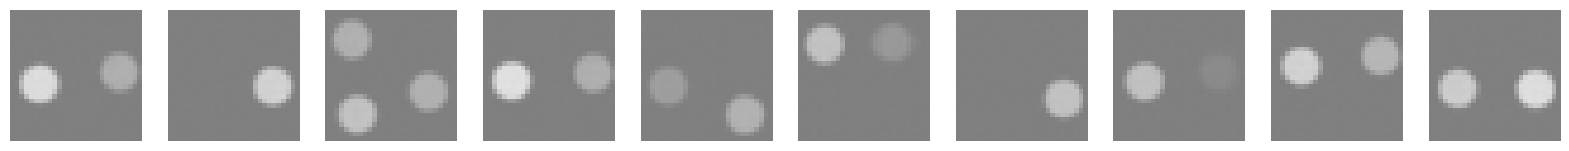

In [13]:
fig, ax = plt.subplots(1, N, figsize=(20, 4))
for idx in range(N):
    ax[idx].imshow(stage1_samples[idx][0].cpu().detach().numpy(), cmap='gray', vmin=-1, vmax=1)
    ax[idx].axis('off')

# latent space

(1000, 6)


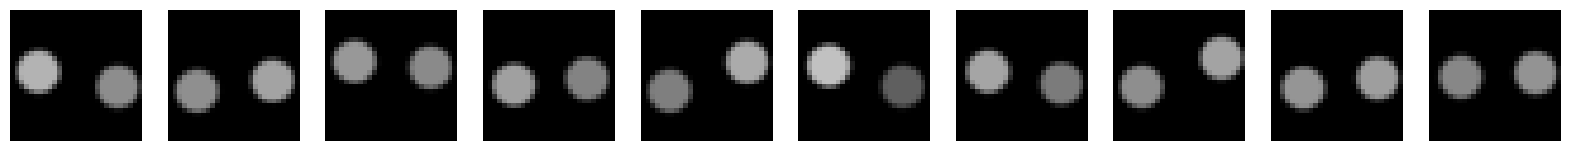

In [43]:
test_input_dataset = cpu_tensor[0:1000]
test_input_dataset_gpu = test_input_dataset.to(device)

# plot
fig, ax = plt.subplots(1, 10, figsize=(20, 4))
for i in range(10):
    ax[i].imshow(test_input_dataset[i].squeeze(), cmap='gray', vmin=-1, vmax=1)
    ax[i].axis('off')

y_mean_d, y_logvar_d, z_mean_d, z_logvar_d = hsami.recnet.x_to_y_to_z(x=test_input_dataset_gpu)

def gpu_to_cpu(tensor):
    return tensor.cpu().detach().numpy()

y_mean_dataset_cpu = gpu_to_cpu(y_mean_d)
y_logvar_dataset_cpu = gpu_to_cpu(y_logvar_d)
z_mean_dataset_cpu = gpu_to_cpu(z_mean_d)
z_logvar_dataset_cpu = gpu_to_cpu(z_logvar_d)
print(y_mean_dataset_cpu.shape)

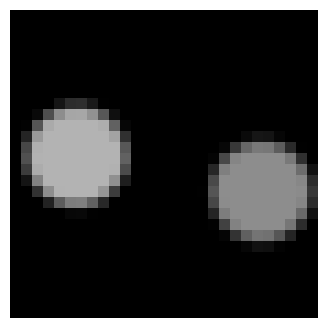

In [48]:
test_input = cpu_tensor[0].unsqueeze(dim=1)
test_input_gpu = test_input.to(device)

# plot
fig, ax = plt.subplots(1, 1, figsize=(20, 4))
ax.imshow(test_input[0].squeeze(), cmap='gray', vmin=-1, vmax=1)
ax.axis('off')

y_mean, y_logvar, z_mean, z_logvar = hsami.recnet.x_to_y_to_z(x=test_input_gpu)
y_samples = hsami.recnet.sample(y_mean, y_logvar)
z_samples = hsami.recnet.sample(z_mean, z_logvar)


def gpu_to_cpu(tensor):
    return tensor.cpu().detach().numpy()

# y_mean_cpu = gpu_to_cpu(y_mean)
# y_logvar_cpu = gpu_to_cpu(y_logvar)
# z_mean_cpu = gpu_to_cpu(z_mean)
# z_logvar_cpu = gpu_to_cpu(z_logvar)

y_samples_cpu = gpu_to_cpu(y_samples)
z_samples_cpu = gpu_to_cpu(z_samples)

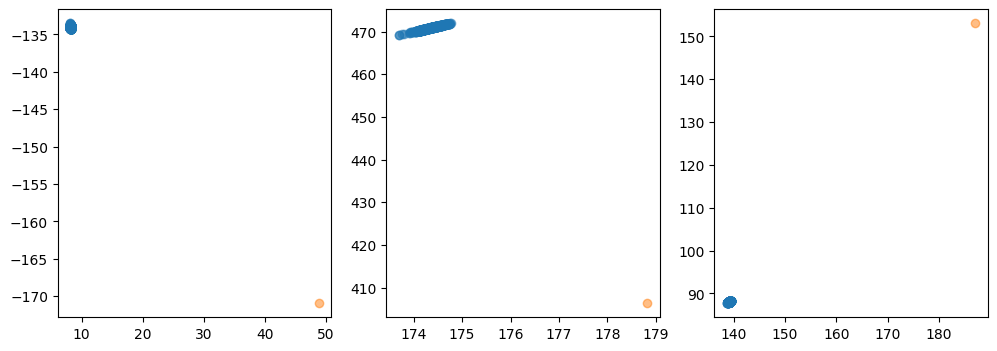

In [49]:
# y_means
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].scatter(*y_mean_dataset_cpu[:, 0:2].T, alpha=0.5)
ax[0].scatter(*y_samples_cpu[:, 0:2].T, alpha=0.5)
ax[1].scatter(*y_mean_dataset_cpu[:, 2:4].T, alpha=0.5)
ax[1].scatter(*y_samples_cpu[:, 2:4].T, alpha=0.5)
ax[2].scatter(*y_mean_dataset_cpu[:, 4:6].T, alpha=0.5)
ax[2].scatter(*y_samples_cpu[:, 4:6].T, alpha=0.5)

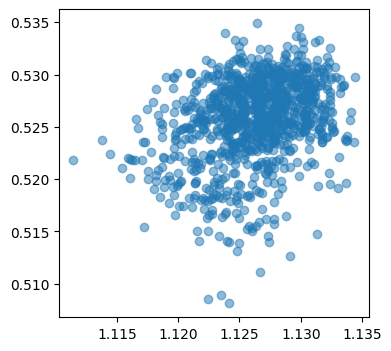

In [ ]:
# y_means
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(*z_mean_cpu[:, 0:2].T, alpha=0.5)